In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostRegressor, AdaBoostClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files
print("Please upload your sustainable energy dataset CSV file:")
uploaded = files.upload()

# Get the filename (assuming single file upload)
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

# Load the dataset
df = pd.read_csv(filename)
print(f"Dataset shape: {df.shape}")

Please upload your sustainable energy dataset CSV file:


Saving energy_data_II.csv to energy_data_II.csv
Uploaded file: energy_data_II.csv
Dataset shape: (2926, 54)


In [3]:
print("Dataset Head:")
print(df.head())

print("\n" + "="*50 + "\n")

# Display column names
print("Column Names:")
print(df.columns.tolist())

print("\n" + "="*50 + "\n")

# Display dataset info
print("Dataset Info:")
print(df.info())

Dataset Head:
  Country Name Country Code  Years  \
0  Afghanistan          AFG   1990   
1  Afghanistan          AFG   2000   
2  Afghanistan          AFG   2013   
3  Afghanistan          AFG   2014   
4  Afghanistan          AFG   2015   

   Access to clean fuels and technologies for cooking (% of population)  \
0                                                NaN                      
1                                               6.70                      
2                                              24.30                      
3                                              25.70                      
4                                              27.25                      

   Access to clean fuels and technologies for cooking, rural (% of rural population)  \
0                                                NaN                                   
1                                                1.1                                   
2                                         

In [4]:
print("Dataset Description:")
print(df.describe())

print("\n" + "="*50 + "\n")

# Check for CO2 Emissions column (case-insensitive search)
co2_columns = [col for col in df.columns if 'co2' in col.lower() or 'emission' in col.lower()]
print("CO2/Emissions related columns found:")
print(co2_columns)

# Check for missing values
print("\n" + "="*50 + "\n")
print("Missing Values:")
print(df.isnull().sum())

Dataset Description:
             Years  \
count  2926.000000   
mean   2013.000000   
std       9.056933   
min    1990.000000   
25%    2013.000000   
50%    2016.000000   
75%    2019.000000   
max    2021.000000   

       Access to clean fuels and technologies for cooking (% of population)  \
count                                        2370.000000                      
mean                                           64.609777                      
std                                            37.274790                      
min                                             0.000000                      
25%                                            26.900000                      
50%                                            81.850000                      
75%                                           100.000000                      
max                                           100.000000                      

       Access to clean fuels and technologies for cooking, rural (% 

In [5]:
co2_column = None
possible_names = ['CO2 Emissions', 'co2_emissions', 'CO2_emissions', 'CO2 emissions',
                  'co2 emissions', 'CO2', 'co2', 'Emissions', 'emissions',
                  'CO2 emissions (kt)', 'CO2 emissions (metric tons per capita)',
                  'Total greenhouse gas emissions (kt of CO2 equivalent)']

for name in possible_names:
    if name in df.columns:
        co2_column = name
        break

if co2_column is None:
    print("CO2 emissions column not found with standard names.")
    print("Available columns:", df.columns.tolist())
    print("Please manually specify the correct column name below:")
    # Manually set the column name here
    co2_column = 'CO2 emissions (kt)'  # Set to the correct column name
    print(f"Manually set CO2 emissions column: '{co2_column}'")
else:
    print(f"Using CO2 emissions column: '{co2_column}'")

# Remove rows with missing CO2 data
df_clean = df.dropna(subset=[co2_column])
print(f"Dataset shape after removing missing CO2 values: {df_clean.shape}")

# Display CO2 emissions statistics
print(f"\n{co2_column} Statistics:")
print(df_clean[co2_column].describe())


Using CO2 emissions column: 'CO2 emissions (kt)'
Dataset shape after removing missing CO2 values: (2389, 54)

CO2 emissions (kt) Statistics:
count    2.389000e+03
mean     1.204216e+06
std      3.923525e+06
min      0.000000e+00
25%      3.209040e+03
50%      2.762910e+04
75%      2.744667e+05
max      3.556056e+07
Name: CO2 emissions (kt), dtype: float64


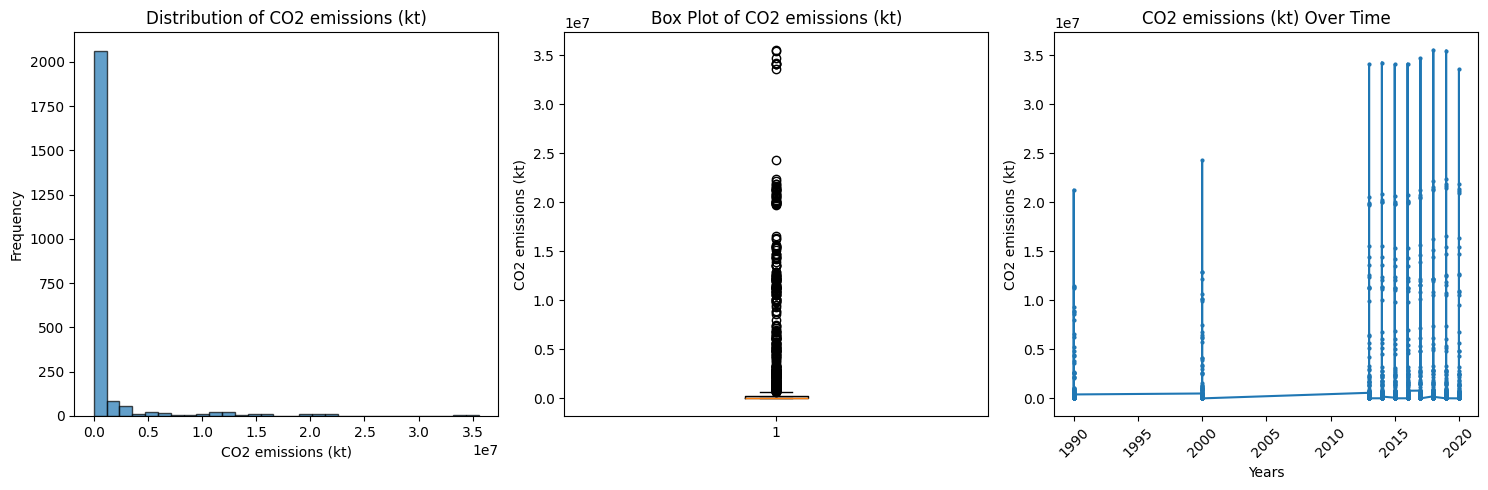

In [6]:
plt.figure(figsize=(15, 5))

# Distribution plot
plt.subplot(1, 3, 1)
plt.hist(df_clean[co2_column], bins=30, edgecolor='black', alpha=0.7)
plt.title(f'Distribution of {co2_column}')
plt.xlabel(co2_column)
plt.ylabel('Frequency')

# Box plot
plt.subplot(1, 3, 2)
plt.boxplot(df_clean[co2_column])
plt.title(f'Box Plot of {co2_column}')
plt.ylabel(co2_column)

# Time series plot (if there's a year/time column)
plt.subplot(1, 3, 3)
time_columns = [col for col in df_clean.columns if any(word in col.lower() for word in ['year', 'date', 'time'])]
if time_columns:
    time_col = time_columns[0]
    df_clean_sorted = df_clean.sort_values(time_col)
    plt.plot(df_clean_sorted[time_col], df_clean_sorted[co2_column], marker='o', markersize=2)
    plt.title(f'{co2_column} Over Time')
    plt.xlabel(time_col)
    plt.ylabel(co2_column)
    plt.xticks(rotation=45)
else:
    plt.plot(df_clean[co2_column])
    plt.title(f'{co2_column} Values')
    plt.xlabel('Index')
    plt.ylabel(co2_column)

plt.tight_layout()
plt.show()

In [7]:
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if co2_column in numerical_cols:
    numerical_cols.remove(co2_column)

print(f"Numerical features available: {len(numerical_cols)}")
print(f"Features: {numerical_cols}")

# Remove features with too many missing values (>50% missing)
features_to_use = []
for col in numerical_cols:
    missing_pct = df_clean[col].isnull().sum() / len(df_clean) * 100
    if missing_pct < 50:
        features_to_use.append(col)
    else:
        print(f"Excluding {col} due to {missing_pct:.1f}% missing values")

print(f"\nFeatures selected for modeling: {len(features_to_use)}")
print(f"Selected features: {features_to_use}")

# Create feature matrix and target vector
X = df_clean[features_to_use].fillna(df_clean[features_to_use].mean())
y = df_clean[co2_column]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Numerical features available: 51
Features: ['Years', 'Access to clean fuels and technologies for cooking (% of population)', 'Access to clean fuels and technologies for cooking, rural (% of rural population)', 'Access to clean fuels and technologies for cooking, urban (% of urban population)', 'Access to electricity (% of population)', 'Access to electricity, rural (% of rural population)', 'Access to electricity, urban (% of urban population)', 'Adjusted savings: energy depletion (% of GNI)', 'Alternative and nuclear energy (% of total energy use)', 'CO2 emissions (metric tons per capita)', 'CO2 emissions from electricity and heat production, total (% of total fuel combustion)', 'CO2 emissions from gaseous fuel consumption (% of total)', 'CO2 emissions from gaseous fuel consumption (kt)', 'CO2 emissions from liquid fuel consumption (% of total)', 'CO2 emissions from liquid fuel consumption (kt)', 'CO2 emissions from manufacturing industries and construction (% of total fuel combustion

In [8]:
print("=== AdaBoost Regression for CO2 Emissions ===")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize AdaBoost Regressor
# Note: base_estimator is now called 'estimator' in newer scikit-learn versions
try:
    ada_regressor = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=100,
        learning_rate=1.0,
        loss='linear',
        random_state=42
    )
except TypeError:
    # Fallback for older scikit-learn versions
    ada_regressor = AdaBoostRegressor(
        base_estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=100,
        learning_rate=1.0,
        loss='linear',
        random_state=42
    )

# Train the model
print("Training AdaBoost Regressor...")
ada_regressor.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = ada_regressor.predict(X_train_scaled)
y_test_pred = ada_regressor.predict(X_test_scaled)

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nRegression Results:")
print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")


=== AdaBoost Regression for CO2 Emissions ===
Training AdaBoost Regressor...

Regression Results:
Training MSE: 47941477304.1078
Testing MSE: 124465600970.8642
Training R²: 0.9969
Testing R²: 0.9913


In [9]:
print("\n=== AdaBoost Classification (High/Low CO2 Emissions) ===")

# Create binary target (above/below median CO2 emissions)
y_median = y.median()
y_binary = (y > y_median).astype(int)
y_binary_labels = y_binary.map({0: 'Low CO2', 1: 'High CO2'})

print(f"CO2 Emissions median: {y_median:.2f}")
print(f"Class distribution:")
print(y_binary_labels.value_counts())

# Check for class balance
unique_classes, class_counts = np.unique(y_binary, return_counts=True)
print(f"Binary class distribution: {dict(zip(unique_classes, class_counts))}")

# Ensure we have enough samples for stratification
min_class_size = min(class_counts)
if min_class_size < 2:
    print("Warning: One class has less than 2 samples. Cannot use stratification.")
    stratify_param = None
else:
    stratify_param = y_binary

# Split the data for classification
try:
    X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
        X, y_binary, test_size=0.2, random_state=42, stratify=stratify_param
    )
    print(f"Train set size: {X_train_clf.shape[0]}, Test set size: {X_test_clf.shape[0]}")
except ValueError as e:
    print(f"Error in train_test_split: {e}")
    print("Trying without stratification...")
    X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
        X, y_binary, test_size=0.2, random_state=42
    )

# Scale the features for classification
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# Initialize AdaBoost Classifier with error handling
print("Initializing AdaBoost Classifier...")
try:
    # For newer scikit-learn versions (>= 1.2)
    ada_classifier = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100,
        learning_rate=1.0,
        algorithm='SAMME',
        random_state=42
    )
except TypeError:
    try:
        # For older scikit-learn versions
        ada_classifier = AdaBoostClassifier(
            base_estimator=DecisionTreeClassifier(max_depth=3),
            n_estimators=100,
            learning_rate=1.0,
            algorithm='SAMME',
            random_state=42
        )
    except Exception as e:
        print(f"Error initializing with SAMME.R: {e}")
        print("Trying with SAMME algorithm...")
        ada_classifier = AdaBoostClassifier(
            n_estimators=100,
            learning_rate=1.0,
            algorithm='SAMME',
            random_state=42
        )

# Train the classifier
print("Training AdaBoost Classifier...")
try:
    ada_classifier.fit(X_train_clf_scaled, y_train_clf)
    print("Training completed successfully!")
except Exception as e:
    print(f"Error during training: {e}")
    print("This might be due to data issues. Checking data...")
    print(f"X_train_clf_scaled shape: {X_train_clf_scaled.shape}")
    print(f"y_train_clf shape: {y_train_clf.shape}")
    print(f"X_train_clf_scaled has NaN: {np.isnan(X_train_clf_scaled).any()}")
    print(f"X_train_clf_scaled has Inf: {np.isinf(X_train_clf_scaled).any()}")
    raise e

# Make predictions
y_train_pred_clf = ada_classifier.predict(X_train_clf_scaled)
y_test_pred_clf = ada_classifier.predict(X_test_clf_scaled)

# Calculate accuracy
train_acc = accuracy_score(y_train_clf, y_train_pred_clf)
test_acc = accuracy_score(y_test_clf, y_test_pred_clf)

print(f"\nClassification Results:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test_clf, y_test_pred_clf, target_names=['Low CO2', 'High CO2']))



=== AdaBoost Classification (High/Low CO2 Emissions) ===
CO2 Emissions median: 27629.10
Class distribution:
CO2 emissions (kt)
Low CO2     1195
High CO2    1194
Name: count, dtype: int64
Binary class distribution: {np.int64(0): np.int64(1195), np.int64(1): np.int64(1194)}
Train set size: 1911, Test set size: 478
Initializing AdaBoost Classifier...
Training AdaBoost Classifier...
Training completed successfully!

Classification Results:
Training Accuracy: 1.0000
Testing Accuracy: 0.9958

Classification Report:
              precision    recall  f1-score   support

     Low CO2       1.00      1.00      1.00       239
    High CO2       1.00      1.00      1.00       239

    accuracy                           1.00       478
   macro avg       1.00      1.00      1.00       478
weighted avg       1.00      1.00      1.00       478



=== Feature Importance Analysis ===
Top 10 Most Important Features:
                                              Feature  Regression_Importance  \
28  Total greenhouse gas emissions (kt of CO2 equi...               0.845559   
18                                 Land area (sq. km)               0.032072   
15  Energy intensity level of primary energy (MJ/$...               0.029495   
8              CO2 emissions (metric tons per capita)               0.025807   
24                                  Population, total               0.012249   
22                                   Population, male               0.010237   
2   Access to clean fuels and technologies for coo...               0.007136   
26  Renewable energy consumption (% of total final...               0.007000   
20                       Population growth (annual %)               0.003260   
6   Access to electricity, urban (% of urban popul...               0.002905   

    Classification_Importance  
28                 

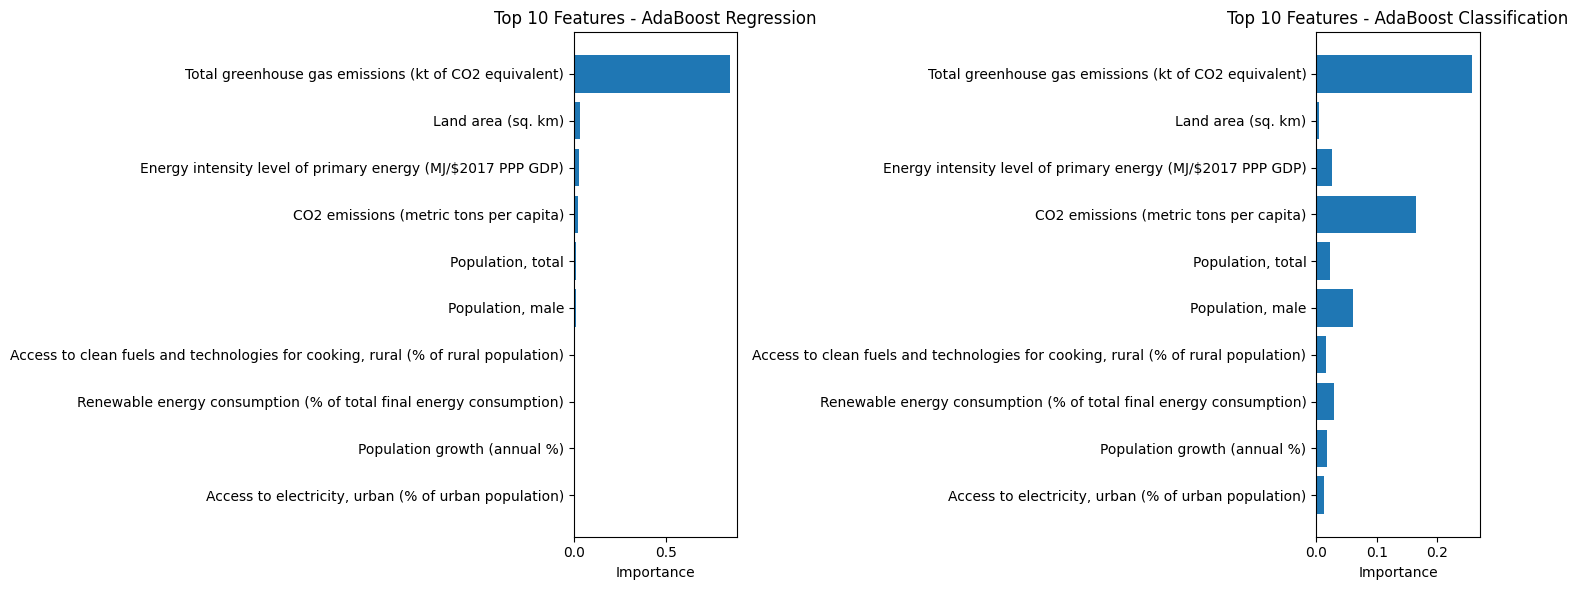

In [10]:
print("=== Feature Importance Analysis ===")

# Get feature importance from both models
reg_importance = ada_regressor.feature_importances_
clf_importance = ada_classifier.feature_importances_

# Create importance DataFrame
importance_df = pd.DataFrame({
    'Feature': features_to_use,
    'Regression_Importance': reg_importance,
    'Classification_Importance': clf_importance
})
importance_df = importance_df.sort_values('Regression_Importance', ascending=False)

print("Top 10 Most Important Features:")
print(importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
top_features = importance_df.head(10)
plt.barh(range(len(top_features)), top_features['Regression_Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 10 Features - AdaBoost Regression')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.barh(range(len(top_features)), top_features['Classification_Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 10 Features - AdaBoost Classification')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

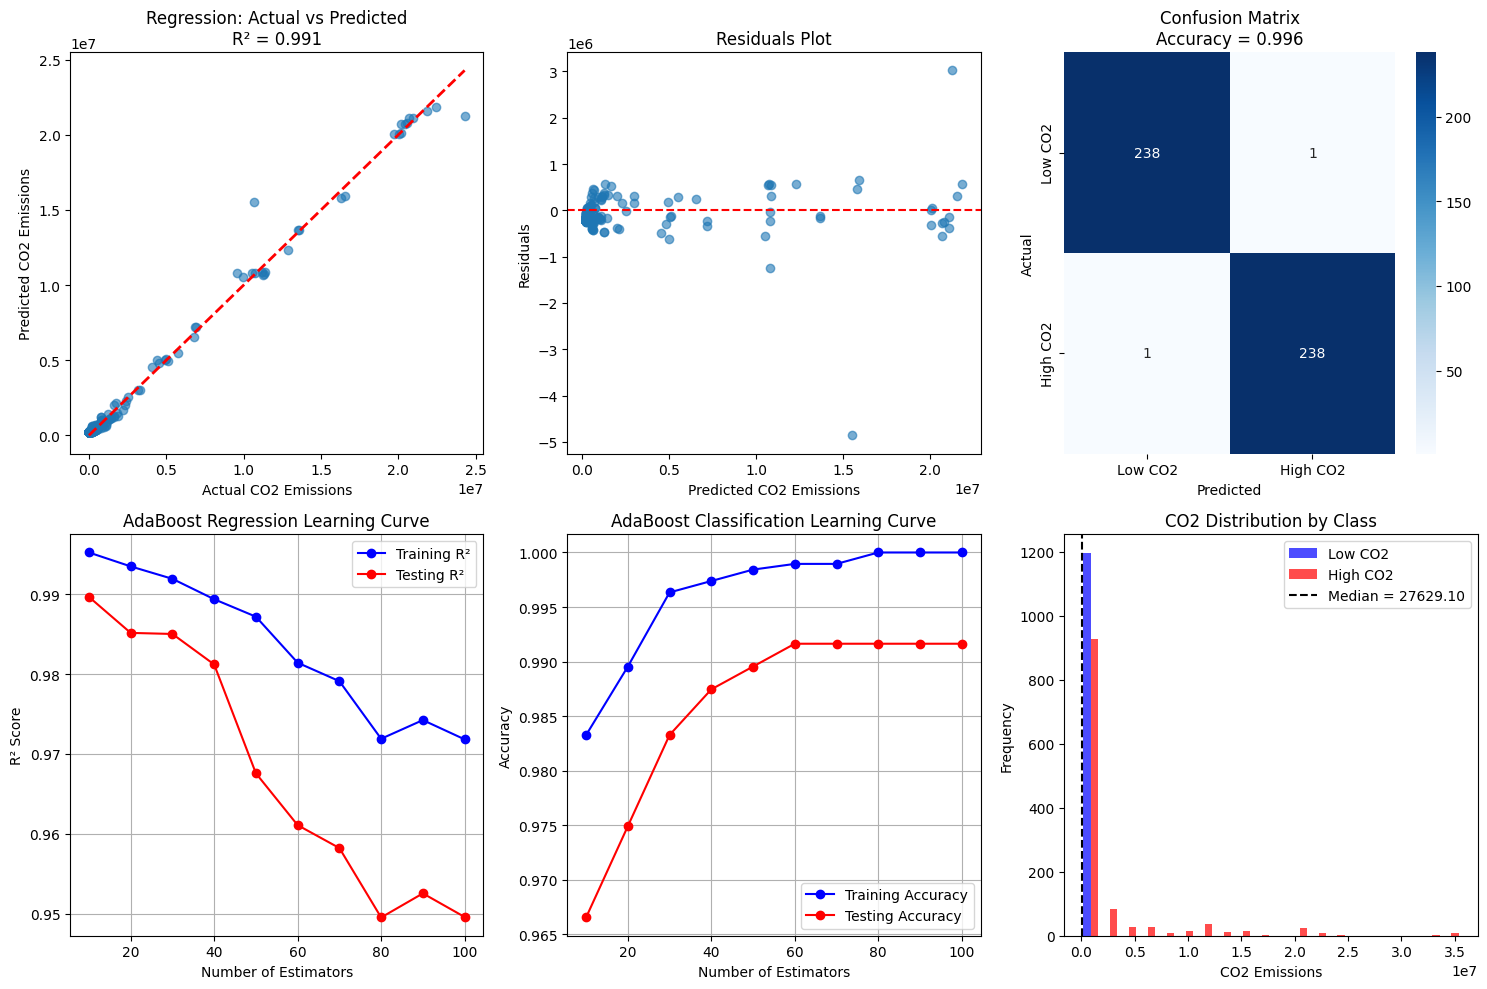

In [11]:
plt.figure(figsize=(15, 10))

# Regression predictions vs actual
plt.subplot(2, 3, 1)
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual CO2 Emissions')
plt.ylabel('Predicted CO2 Emissions')
plt.title(f'Regression: Actual vs Predicted\nR² = {test_r2:.3f}')

# Residuals plot
plt.subplot(2, 3, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted CO2 Emissions')
plt.ylabel('Residuals')
plt.title('Residuals Plot')

# Classification confusion matrix visualization
plt.subplot(2, 3, 3)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_clf, y_test_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low CO2', 'High CO2'],
            yticklabels=['Low CO2', 'High CO2'])
plt.title(f'Confusion Matrix\nAccuracy = {test_acc:.3f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Learning curves for regression
plt.subplot(2, 3, 4)
train_sizes = np.arange(10, 101, 10)
train_scores_reg = []
test_scores_reg = []

for n_est in train_sizes:
    temp_model = AdaBoostRegressor(n_estimators=n_est, random_state=42)
    temp_model.fit(X_train_scaled, y_train)
    train_pred = temp_model.predict(X_train_scaled)
    test_pred = temp_model.predict(X_test_scaled)
    train_scores_reg.append(r2_score(y_train, train_pred))
    test_scores_reg.append(r2_score(y_test, test_pred))

plt.plot(train_sizes, train_scores_reg, 'o-', label='Training R²', color='blue')
plt.plot(train_sizes, test_scores_reg, 'o-', label='Testing R²', color='red')
plt.xlabel('Number of Estimators')
plt.ylabel('R² Score')
plt.title('AdaBoost Regression Learning Curve')
plt.legend()
plt.grid(True)

# Learning curves for classification
plt.subplot(2, 3, 5)
train_scores_clf = []
test_scores_clf = []

for n_est in train_sizes:
    temp_model = AdaBoostClassifier(n_estimators=n_est, random_state=42)
    temp_model.fit(X_train_clf, y_train_clf)
    train_pred = temp_model.predict(X_train_clf)
    test_pred = temp_model.predict(X_test_clf)
    train_scores_clf.append(accuracy_score(y_train_clf, train_pred))
    test_scores_clf.append(accuracy_score(y_test_clf, test_pred))

plt.plot(train_sizes, train_scores_clf, 'o-', label='Training Accuracy', color='blue')
plt.plot(train_sizes, test_scores_clf, 'o-', label='Testing Accuracy', color='red')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('AdaBoost Classification Learning Curve')
plt.legend()
plt.grid(True)

# CO2 distribution by predicted class
plt.subplot(2, 3, 6)
low_co2 = y[y_binary == 0]
high_co2 = y[y_binary == 1]
plt.hist([low_co2, high_co2], bins=20, alpha=0.7, label=['Low CO2', 'High CO2'], color=['blue', 'red'])
plt.axvline(y_median, color='black', linestyle='--', label=f'Median = {y_median:.2f}')
plt.xlabel('CO2 Emissions')
plt.ylabel('Frequency')
plt.title('CO2 Distribution by Class')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
print("=== Cross-Validation Results ===")

# Cross-validation for regression
cv_scores_reg = cross_val_score(ada_regressor, X_train_scaled, y_train,
                               cv=5, scoring='r2')
print(f"Regression CV R² scores: {cv_scores_reg}")
print(f"Mean CV R²: {cv_scores_reg.mean():.4f} (+/- {cv_scores_reg.std() * 2:.4f})")

# Cross-validation for classification
cv_scores_clf = cross_val_score(ada_classifier, X_train_clf_scaled, y_train_clf,
                               cv=5, scoring='accuracy')
print(f"Classification CV Accuracy scores: {cv_scores_clf}")
print(f"Mean CV Accuracy: {cv_scores_clf.mean():.4f} (+/- {cv_scores_clf.std() * 2:.4f})")

print("\n=== Hyperparameter Tuning ===")

# Updated parameter grid for regression (using 'estimator' instead of 'base_estimator')
param_grid_reg = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.5, 1.0, 1.5],
    'estimator__max_depth': [3, 4, 5]  # Changed from 'base_estimator__max_depth'
}

print("Performing Grid Search for Regression...")
try:
    # Try with newer scikit-learn parameter naming
    grid_search_reg = GridSearchCV(
        AdaBoostRegressor(
            estimator=DecisionTreeRegressor(random_state=42),
            random_state=42
        ),
        param_grid_reg,
        cv=3,
        scoring='r2',
        n_jobs=-1
    )
except TypeError:
    # Fallback for older scikit-learn versions
    param_grid_reg_old = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.5, 1.0, 1.5],
        'base_estimator__max_depth': [3, 4, 5]
    }
    grid_search_reg = GridSearchCV(
        AdaBoostRegressor(
            base_estimator=DecisionTreeRegressor(random_state=42),
            random_state=42
        ),
        param_grid_reg_old,
        cv=3,
        scoring='r2',
        n_jobs=-1
    )

grid_search_reg.fit(X_train_scaled, y_train)

print(f"Best parameters for regression: {grid_search_reg.best_params_}")
print(f"Best CV score for regression: {grid_search_reg.best_score_:.4f}")

# Updated parameter grid for classification (using 'estimator' instead of 'base_estimator')
param_grid_clf = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.5, 1.0, 1.5],
    'estimator__max_depth': [3, 4, 5]  # Changed from 'base_estimator__max_depth'
}

print("\nPerforming Grid Search for Classification...")
try:
    # Try with newer scikit-learn parameter naming
    grid_search_clf = GridSearchCV(
        AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            random_state=42
        ),
        param_grid_clf,
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )
except TypeError:
    # Fallback for older scikit-learn versions
    param_grid_clf_old = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.5, 1.0, 1.5],
        'base_estimator__max_depth': [3, 4, 5]
    }
    grid_search_clf = GridSearchCV(
        AdaBoostClassifier(
            base_estimator=DecisionTreeClassifier(random_state=42),
            random_state=42
        ),
        param_grid_clf_old,
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )

grid_search_clf.fit(X_train_clf_scaled, y_train_clf)

print(f"Best parameters for classification: {grid_search_clf.best_params_}")
print(f"Best CV score for classification: {grid_search_clf.best_score_:.4f}")


=== Cross-Validation Results ===
Regression CV R² scores: [0.99385782 0.9965439  0.9976218  0.99600363 0.9923456 ]
Mean CV R²: 0.9953 (+/- 0.0038)
Classification CV Accuracy scores: [0.9921671  0.98691099 0.9921466  0.9973822  0.9895288 ]
Mean CV Accuracy: 0.9916 (+/- 0.0069)

=== Hyperparameter Tuning ===
Performing Grid Search for Regression...
Best parameters for regression: {'estimator__max_depth': 5, 'learning_rate': 1.0, 'n_estimators': 150}
Best CV score for regression: 0.9936

Performing Grid Search for Classification...
Best parameters for classification: {'estimator__max_depth': 4, 'learning_rate': 1.5, 'n_estimators': 50}
Best CV score for classification: 0.9927


In [13]:
print("=== Final Model Evaluation ===")

# Train final models with best parameters
final_reg_model = grid_search_reg.best_estimator_
final_clf_model = grid_search_clf.best_estimator_

# Final predictions
final_reg_pred = final_reg_model.predict(X_test_scaled)
final_clf_pred = final_clf_model.predict(X_test_clf)

# Final metrics
final_reg_r2 = r2_score(y_test, final_reg_pred)
final_reg_mse = mean_squared_error(y_test, final_reg_pred)
final_clf_acc = accuracy_score(y_test_clf, final_clf_pred)

print(f"Final Regression Model:")
print(f"  R² Score: {final_reg_r2:.4f}")
print(f"  MSE: {final_reg_mse:.4f}")
print(f"  RMSE: {np.sqrt(final_reg_mse):.4f}")

print(f"\nFinal Classification Model:")
print(f"  Accuracy: {final_clf_acc:.4f}")

print(f"\nModel Summary:")
print(f"Dataset: Sustainable Energy and Environmental Data")
print(f"Target Variable: {co2_column}")
print(f"Number of Features: {len(features_to_use)}")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"Best Regression R²: {final_reg_r2:.4f}")
print(f"Best Classification Accuracy: {final_clf_acc:.4f}")

# Save feature importance
final_importance = pd.DataFrame({
    'Feature': features_to_use,
    'Importance': final_reg_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 5 Most Important Features:")
print(final_importance.head())

print("\nAdaBoost implementation completed successfully!")

=== Final Model Evaluation ===
Final Regression Model:
  R² Score: 0.9953
  MSE: 66272807096.5947
  RMSE: 257435.0541

Final Classification Model:
  Accuracy: 0.5000

Model Summary:
Dataset: Sustainable Energy and Environmental Data
Target Variable: CO2 emissions (kt)
Number of Features: 29
Training Samples: 1911
Testing Samples: 478
Best Regression R²: 0.9953
Best Classification Accuracy: 0.5000

Top 5 Most Important Features:
                                              Feature  Importance
28  Total greenhouse gas emissions (kt of CO2 equi...    0.846407
18                                 Land area (sq. km)    0.057209
15  Energy intensity level of primary energy (MJ/$...    0.022636
24                                  Population, total    0.018705
22                                   Population, male    0.012085

AdaBoost implementation completed successfully!


=== ROC Curve Analysis ===
AUC Score: 0.9999


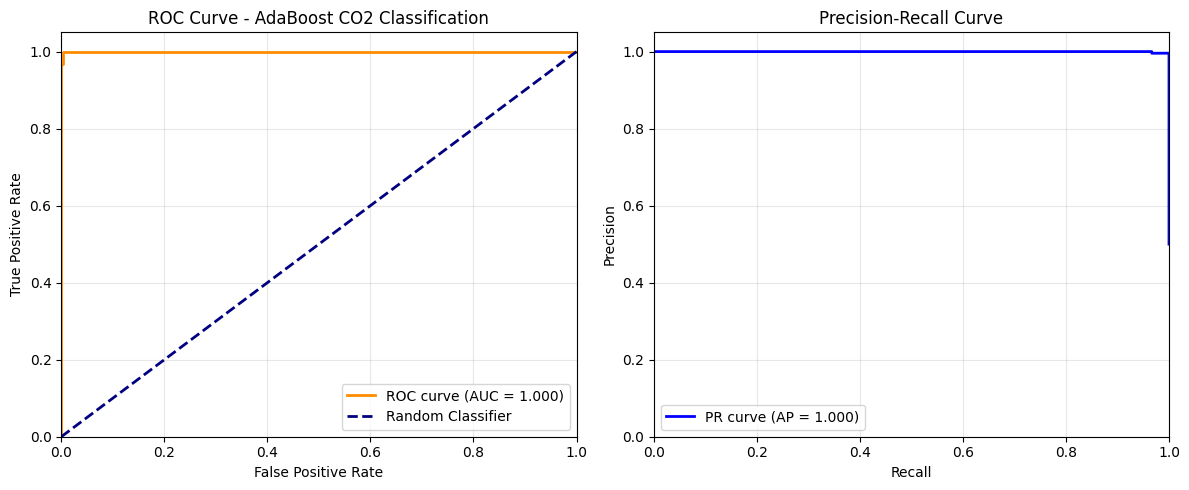


=== ROC Curve Interpretation ===
AUC Score: 0.9999
Model Performance: Excellent
Average Precision: 0.9999

Optimal Threshold: 0.4606
At optimal threshold - TPR: 1.0000, FPR: 0.0042

=== Model Comparison ===
Original AdaBoost AUC: 0.9996
Optimized AdaBoost AUC: 0.9999
Improvement: 0.0003


In [14]:
# CELL 14: ROC Curve Analysis
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

print("=== ROC Curve Analysis ===")

# Get prediction probabilities for the positive class (High CO2)
# Use the final optimized classifier from your grid search
y_test_proba = final_clf_model.predict_proba(X_test_clf_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_test_proba)

# Calculate AUC (Area Under Curve)
auc_score = roc_auc_score(y_test_clf, y_test_proba)

print(f"AUC Score: {auc_score:.4f}")

# Create ROC curve plot
plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AdaBoost CO2 Classification')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Precision-Recall Curve (bonus)
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test_clf, y_test_proba)
avg_precision = average_precision_score(y_test_clf, y_test_proba)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ROC curve interpretation
print(f"\n=== ROC Curve Interpretation ===")
print(f"AUC Score: {auc_score:.4f}")

if auc_score >= 0.9:
    interpretation = "Excellent"
elif auc_score >= 0.8:
    interpretation = "Good"
elif auc_score >= 0.7:
    interpretation = "Fair"
elif auc_score >= 0.6:
    interpretation = "Poor"
else:
    interpretation = "Very Poor"

print(f"Model Performance: {interpretation}")
print(f"Average Precision: {avg_precision:.4f}")

# Find optimal threshold using Youden's J statistic
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

print(f"\nOptimal Threshold: {optimal_threshold:.4f}")
print(f"At optimal threshold - TPR: {optimal_tpr:.4f}, FPR: {optimal_fpr:.4f}")

# Compare with different models (optional - using original non-optimized model)
print(f"\n=== Model Comparison ===")
original_proba = ada_classifier.predict_proba(X_test_clf_scaled)[:, 1]
original_auc = roc_auc_score(y_test_clf, original_proba)

print(f"Original AdaBoost AUC: {original_auc:.4f}")
print(f"Optimized AdaBoost AUC: {auc_score:.4f}")
print(f"Improvement: {auc_score - original_auc:.4f}")


=== Multi-Model ROC Comparison ===


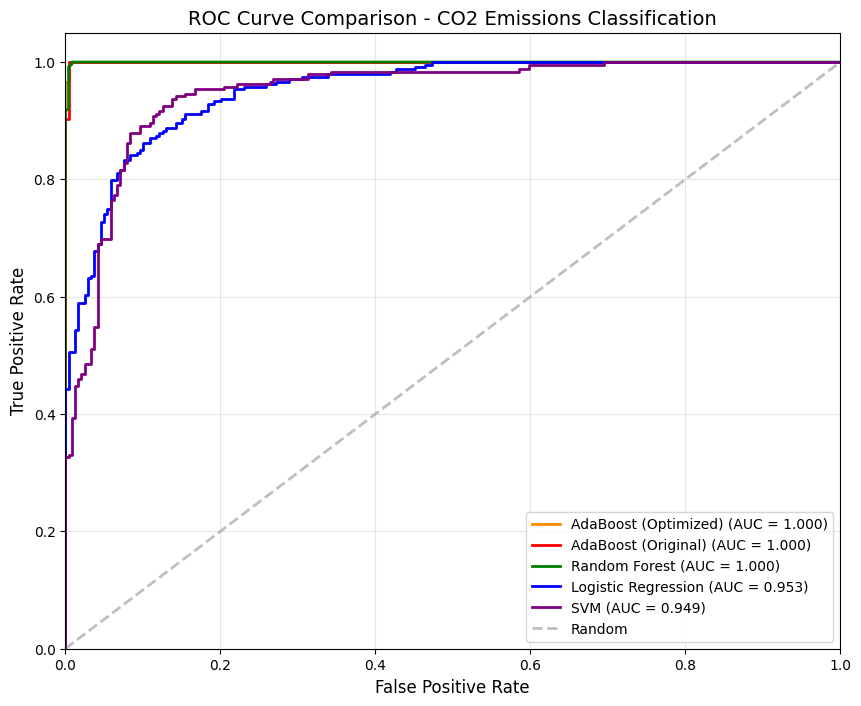


=== Model Performance Ranking ===
1. AdaBoost (Optimized): 0.9999
2. Random Forest: 0.9996
3. AdaBoost (Original): 0.9996
4. Logistic Regression: 0.9527
5. SVM: 0.9491

Best performing model: AdaBoost (Optimized) with AUC = 0.9999


In [15]:
# CELL 15: ROC Curve Comparison with Other Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

print("=== Multi-Model ROC Comparison ===")

# Train additional models for comparison
models = {
    'AdaBoost (Optimized)': final_clf_model,
    'AdaBoost (Original)': ada_classifier,
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42)
}

# Train additional models
for name, model in models.items():
    if name not in ['AdaBoost (Optimized)', 'AdaBoost (Original)']:
        model.fit(X_train_clf_scaled, y_train_clf)

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))
colors = ['darkorange', 'red', 'green', 'blue', 'purple']

auc_scores = {}
for i, (name, model) in enumerate(models.items()):
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_clf_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_clf_scaled)

    fpr_temp, tpr_temp, _ = roc_curve(y_test_clf, y_proba)
    auc_temp = roc_auc_score(y_test_clf, y_proba)
    auc_scores[name] = auc_temp

    plt.plot(fpr_temp, tpr_temp, color=colors[i], lw=2,
             label=f'{name} (AUC = {auc_temp:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', alpha=0.5, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - CO2 Emissions Classification', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# Print AUC scores ranking
print(f"\n=== Model Performance Ranking ===")
sorted_scores = sorted(auc_scores.items(), key=lambda x: x[1], reverse=True)
for i, (model_name, score) in enumerate(sorted_scores, 1):
    print(f"{i}. {model_name}: {score:.4f}")

print(f"\nBest performing model: {sorted_scores[0][0]} with AUC = {sorted_scores[0][1]:.4f}")
